In [1]:
import scanpy as sc
import numpy as np
import flowkit as fk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from preprocessing import read_flow
fcs_dir = str(input("Path"))
tissue_type = input(str("Tissue type"))
df_flow, sample_list, session = read_flow(fcs_dir)

Parameters: Index(['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A',
       'Clec9a', 'LD_CD326', 'HLADR', 'CD56', 'KI67', 'CD19', 'CD3', 'CD163',
       'CD33', 'CD4', 'CD16', 'IgE', 'CD1c', 'CD206', 'CD11b', 'CD127',
       'CD117', 'CCR3', 'CD49d', 'CD11c', 'CD169', 'CRTH2', 'FceRIa', 'CD103',
       'CD45', 'CD66b', 'IL33R', 'CD14', 'CD123', 'Time', 'sample_id',
       'condition', 'Ki67'],
      dtype='object')


In [5]:
exclude = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A', 'LD_CD326', 'Time', 'CD45', 'CD4']
df_flow = df_flow.drop(columns=exclude)

In [7]:
df_flow.keys()

Index(['Clec9a', 'HLADR', 'CD56', 'KI67', 'CD19', 'CD3', 'CD163', 'CD33',
       'CD16', 'IgE', 'CD1c', 'CD206', 'CD11b', 'CD127', 'CD117', 'CCR3',
       'CD49d', 'CD11c', 'CD169', 'CRTH2', 'FceRIa', 'CD103', 'CD66b', 'IL33R',
       'CD14', 'CD123', 'sample_id', 'condition', 'Ki67'],
      dtype='object')

In [8]:
df_flow['Ki67'] = df_flow[['Ki67', 'KI67']].max(axis=1)
# df_flow['HLADR'] = df_flow[['HLA-DR', 'HLADR']].max(axis=1)
df_flow.drop(columns = ['KI67'], inplace=True)
# df_flow.drop(columns = ['HLA-DR'], inplace=True)

In [9]:
df_flow_counts = df_flow.select_dtypes(include=[np.number])

In [10]:
from preprocessing import pd_to_adata
adata = pd_to_adata(df_flow, df_flow_counts)

In [11]:
sc.pp.scale(adata, max_value=5)

In [12]:
adata

AnnData object with n_obs × n_vars = 11677115 × 26
    obs: 'group', 'sample_id'
    var: 'mean', 'std'

In [13]:
CD3pCD19n = adata[(adata[:, 'CD3'].X > 0)]
CD3pCD19n = CD3pCD19n[:, CD3pCD19n.var.index != 'CD3']
CD3pCD19n = CD3pCD19n[(CD3pCD19n[:, 'CD19'].X < 0)]
CD3pCD19n = CD3pCD19n[:, CD3pCD19n.var.index != 'CD19']

adata_list = [
    (lambda subset, group: (
        subset[np.random.choice(
            subset.shape[0],
            min(20000, subset.shape[0]),
            replace=False
        )].copy()
    ))(CD3pCD19n[CD3pCD19n.obs['group'] == group].copy(), group)
    for group in ['ctr', 'hst', 'ftl']
]

for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

CD3pCD19n = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [14]:
CD3nCD19p = adata[(adata[:, 'CD3'].X < 0)]
CD3nCD19p = CD3nCD19p[:, CD3nCD19p.var.index != 'CD3']
CD3nCD19p = CD3nCD19p[(CD3nCD19p[:, 'CD19'].X > 0)]
CD3nCD19p = CD3nCD19p[:, CD3nCD19p.var.index != 'CD19']

adata_list = [
    (lambda subset, group: (
        subset[np.random.choice(
            subset.shape[0],
            min(20000, subset.shape[0]),
            replace=False
        )].copy()
    ))(CD3nCD19p[CD3nCD19p.obs['group'] == group].copy(), group)
    for group in ['ctr', 'hst', 'ftl']
]

for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

CD3nCD19p = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [15]:
CD3nCD19nCD33pCD14p = adata[(adata[:,'CD3'].X < 0)]
CD3nCD19nCD33pCD14p = CD3nCD19nCD33pCD14p[:, CD3nCD19nCD33pCD14p.var.index != 'CD3']
CD3nCD19nCD33pCD14p = CD3nCD19nCD33pCD14p[(CD3nCD19nCD33pCD14p[:, 'CD19'].X < 0)]
CD3nCD19nCD33pCD14p = CD3nCD19nCD33pCD14p[:, CD3nCD19nCD33pCD14p.var.index != 'CD19']
CD3nCD19nCD33pCD14p = CD3nCD19nCD33pCD14p[(CD3nCD19nCD33pCD14p[:, 'CD33'].X > 0)]
CD3nCD19nCD33pCD14p = CD3nCD19nCD33pCD14p[:, CD3nCD19nCD33pCD14p.var.index != 'CD33']
CD3nCD19nCD33pCD14p = CD3nCD19nCD33pCD14p[(CD3nCD19nCD33pCD14p[:,'CD14'].X > 0)]
CD3nCD19nCD33pCD14p = CD3nCD19nCD33pCD14p[:, CD3nCD19nCD33pCD14p.var.index != 'CD14']

adata_list = [
    (lambda subset, group: (
        subset[np.random.choice(
            subset.shape[0],
            min(20000, subset.shape[0]),
            replace=False
        )].copy()
    ))(CD3nCD19nCD33pCD14p[CD3nCD19nCD33pCD14p.obs['group'] == group].copy(), group)
    for group in ['ctr', 'hst', 'ftl']
]

for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

CD3nCD19nCD33pCD14p = sc.AnnData.concatenate(*adata_list, index_unique=None)


In [16]:
CD3nCD19nCD33pCD14n = adata[(adata[:,'CD3'].X < 0)]
CD3nCD19nCD33pCD14n = CD3nCD19nCD33pCD14n[:, CD3nCD19nCD33pCD14n.var.index != 'CD3']
CD3nCD19nCD33pCD14n = CD3nCD19nCD33pCD14n[(CD3nCD19nCD33pCD14n[:,'CD19'].X < 0)]
CD3nCD19nCD33pCD14n = CD3nCD19nCD33pCD14n[:, CD3nCD19nCD33pCD14n.var.index != 'CD19']
CD3nCD19nCD33pCD14n = CD3nCD19nCD33pCD14n[(CD3nCD19nCD33pCD14n[:,'CD33'].X > 0)]
CD3nCD19nCD33pCD14n = CD3nCD19nCD33pCD14n[:, CD3nCD19nCD33pCD14n.var.index != 'CD33']
CD3nCD19nCD33pCD14n = CD3nCD19nCD33pCD14n[(CD3nCD19nCD33pCD14n[:,'CD14'].X < 0)]
CD3nCD19nCD33pCD14n = CD3nCD19nCD33pCD14n[:, CD3nCD19nCD33pCD14n.var.index != 'CD14']

adata_list = [
    (lambda subset, group: (
        subset[np.random.choice(
            subset.shape[0],
            min(20000, subset.shape[0]),
            replace=False
        )].copy()
    ))(CD3nCD19nCD33pCD14n[CD3nCD19nCD33pCD14n.obs['group'] == group].copy(), group)
    for group in ['ctr', 'hst', 'ftl']
]

for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

CD3nCD19nCD33pCD14n = sc.AnnData.concatenate(*adata_list, index_unique=None)


In [17]:
CD3nCD19nCD33n = adata[(adata[:, 'CD3'].X < 0)]
CD3nCD19nCD33n = CD3nCD19nCD33n[:, CD3nCD19nCD33n.var.index != 'CD3']
CD3nCD19nCD33n = CD3nCD19nCD33n[(CD3nCD19nCD33n[:, 'CD19'].X < 0)]
CD3nCD19nCD33n = CD3nCD19nCD33n[:, CD3nCD19nCD33n.var.index != 'CD19']
CD3nCD19nCD33n = CD3nCD19nCD33n[(CD3nCD19nCD33n[:, 'CD33'].X < 0)]
CD3nCD19nCD33n = CD3nCD19nCD33n[:, CD3nCD19nCD33n.var.index != 'CD33']

adata_list = [
    (lambda subset, group: (
        subset[np.random.choice(
            subset.shape[0],
            min(20000, subset.shape[0]),
            replace=False
        )].copy()
    ))(CD3nCD19nCD33n[CD3nCD19nCD33n.obs['group'] == group].copy(), group)
    for group in ['ctr', 'hst', 'ftl']
]

for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

CD3nCD19nCD33n = sc.AnnData.concatenate(*adata_list, index_unique=None)


In [18]:
sample = CD3pCD19n
sample_name = 'CD3+CD19-'

In [19]:
sc.settings.verbosity = 3

In [20]:
plt.rcParams.update({'font.size': 10})  

computing PCA
    with n_comps=23
    finished (0:00:04)


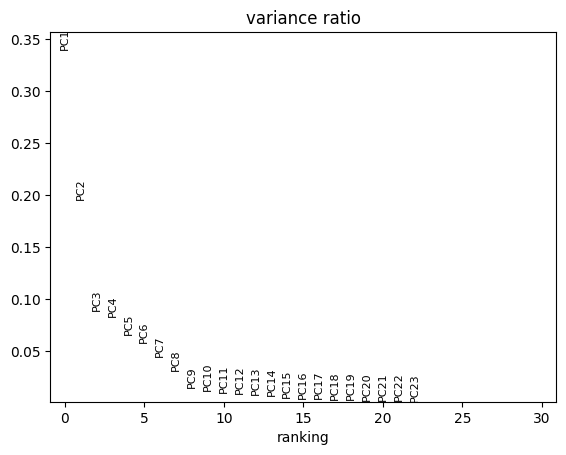

In [21]:
sc.tl.pca(sample, svd_solver="arpack")
sc.pl.pca_variance_ratio(sample, log=False)

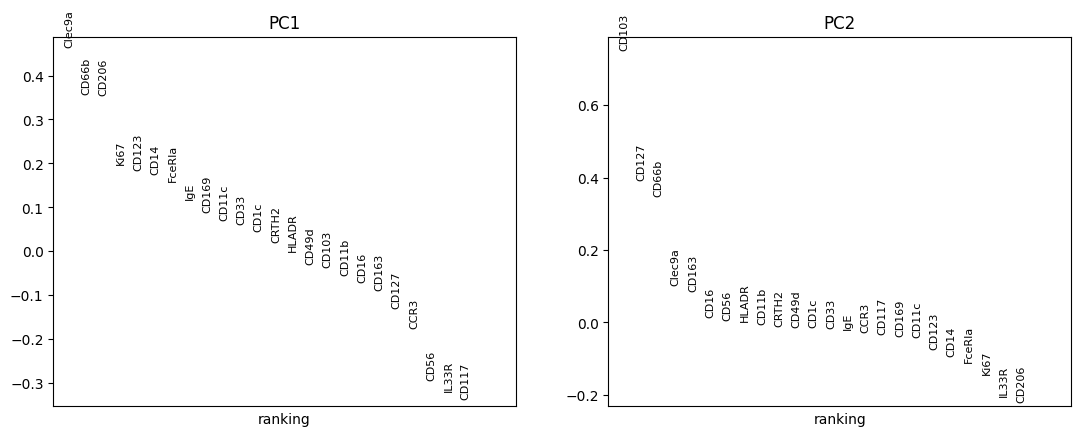

In [22]:
sc.pl.pca_loadings(sample, components = '1,2')

In [23]:
from preprocessing import pca_df
grouped_pca = pca_df(sample, session)

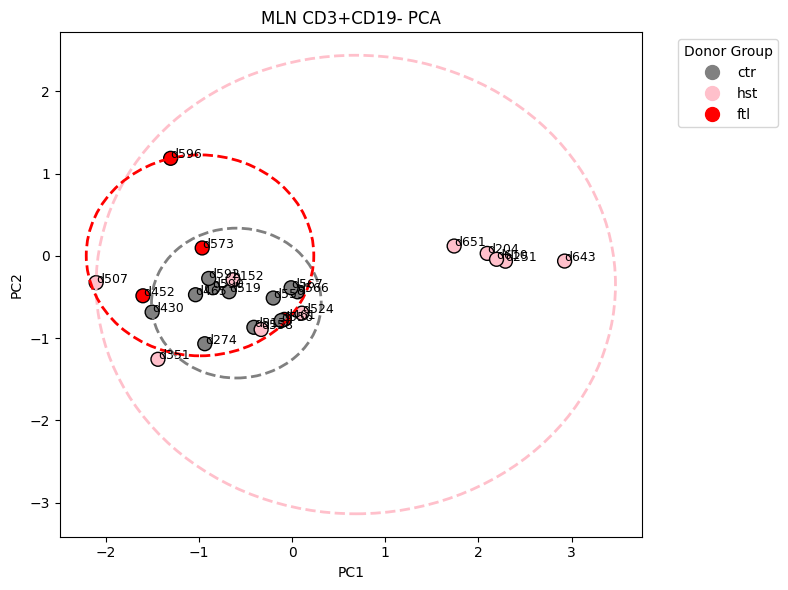

In [24]:
from plotting_methods import pca_plot
pca_plot(grouped_pca, tissue_type, sample_name)

In [25]:
sc.external.pp.harmony_integrate(sample, key='sample_id', max_iter_harmony=20)
sc.pp.neighbors(sample, use_rep='X_pca_harmony')
sc.tl.umap(sample)

2026-02-16 16:39:57,802 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-02-16 16:40:03,782 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-02-16 16:40:04,153 - harmonypy - INFO - Iteration 1 of 20
2026-02-16 16:40:27,531 - harmonypy - INFO - Iteration 2 of 20
2026-02-16 16:40:48,438 - harmonypy - INFO - Converged after 2 iterations


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:38)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:36)


In [26]:
markers = list(sample.var_names)

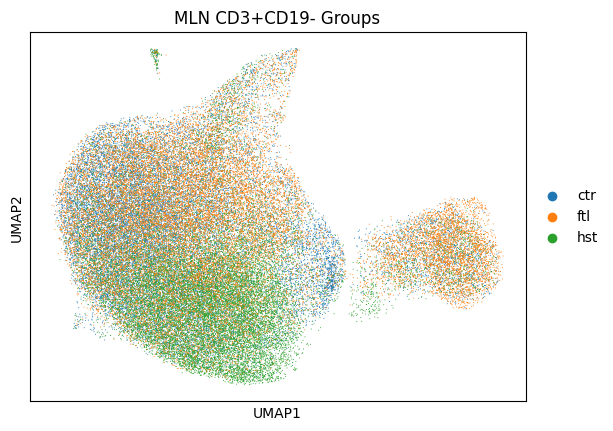

In [27]:
sc.pl.umap(sample, color= ['group'], cmap='turbo', title = '{} {} Groups'.format(tissue_type, sample_name))

In [28]:
sc.tl.leiden(sample, resolution=0.6, flavor='leidenalg')

running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:56)


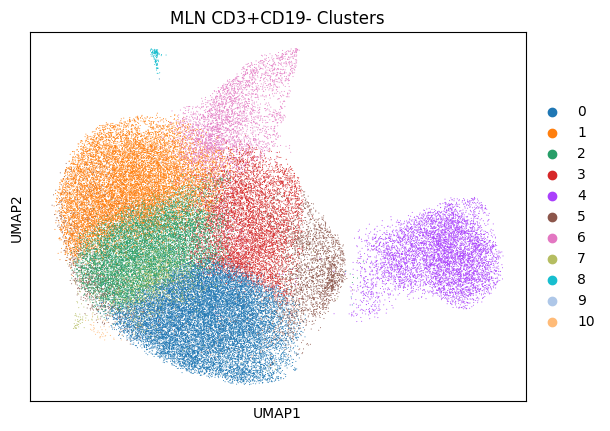

In [29]:
sc.pl.umap(sample, color= ['leiden'], cmap='turbo', title = '{} {} Clusters'.format(tissue_type, sample_name))

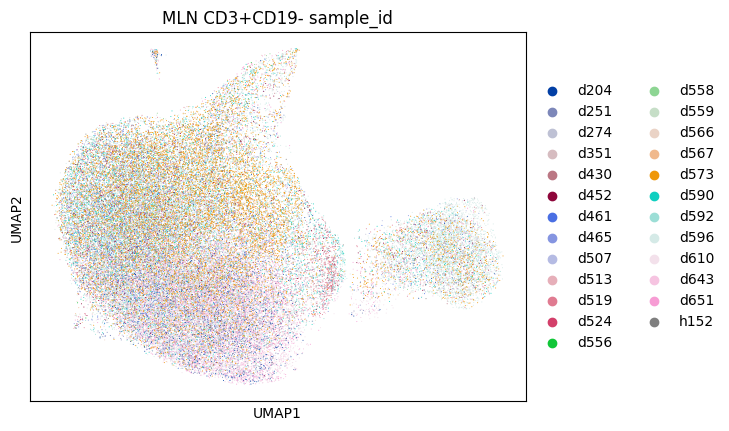

In [30]:
sc.pl.umap(sample, color= ['sample_id'], cmap='turbo',  title = '{} {} sample_id'.format(tissue_type, sample_name))

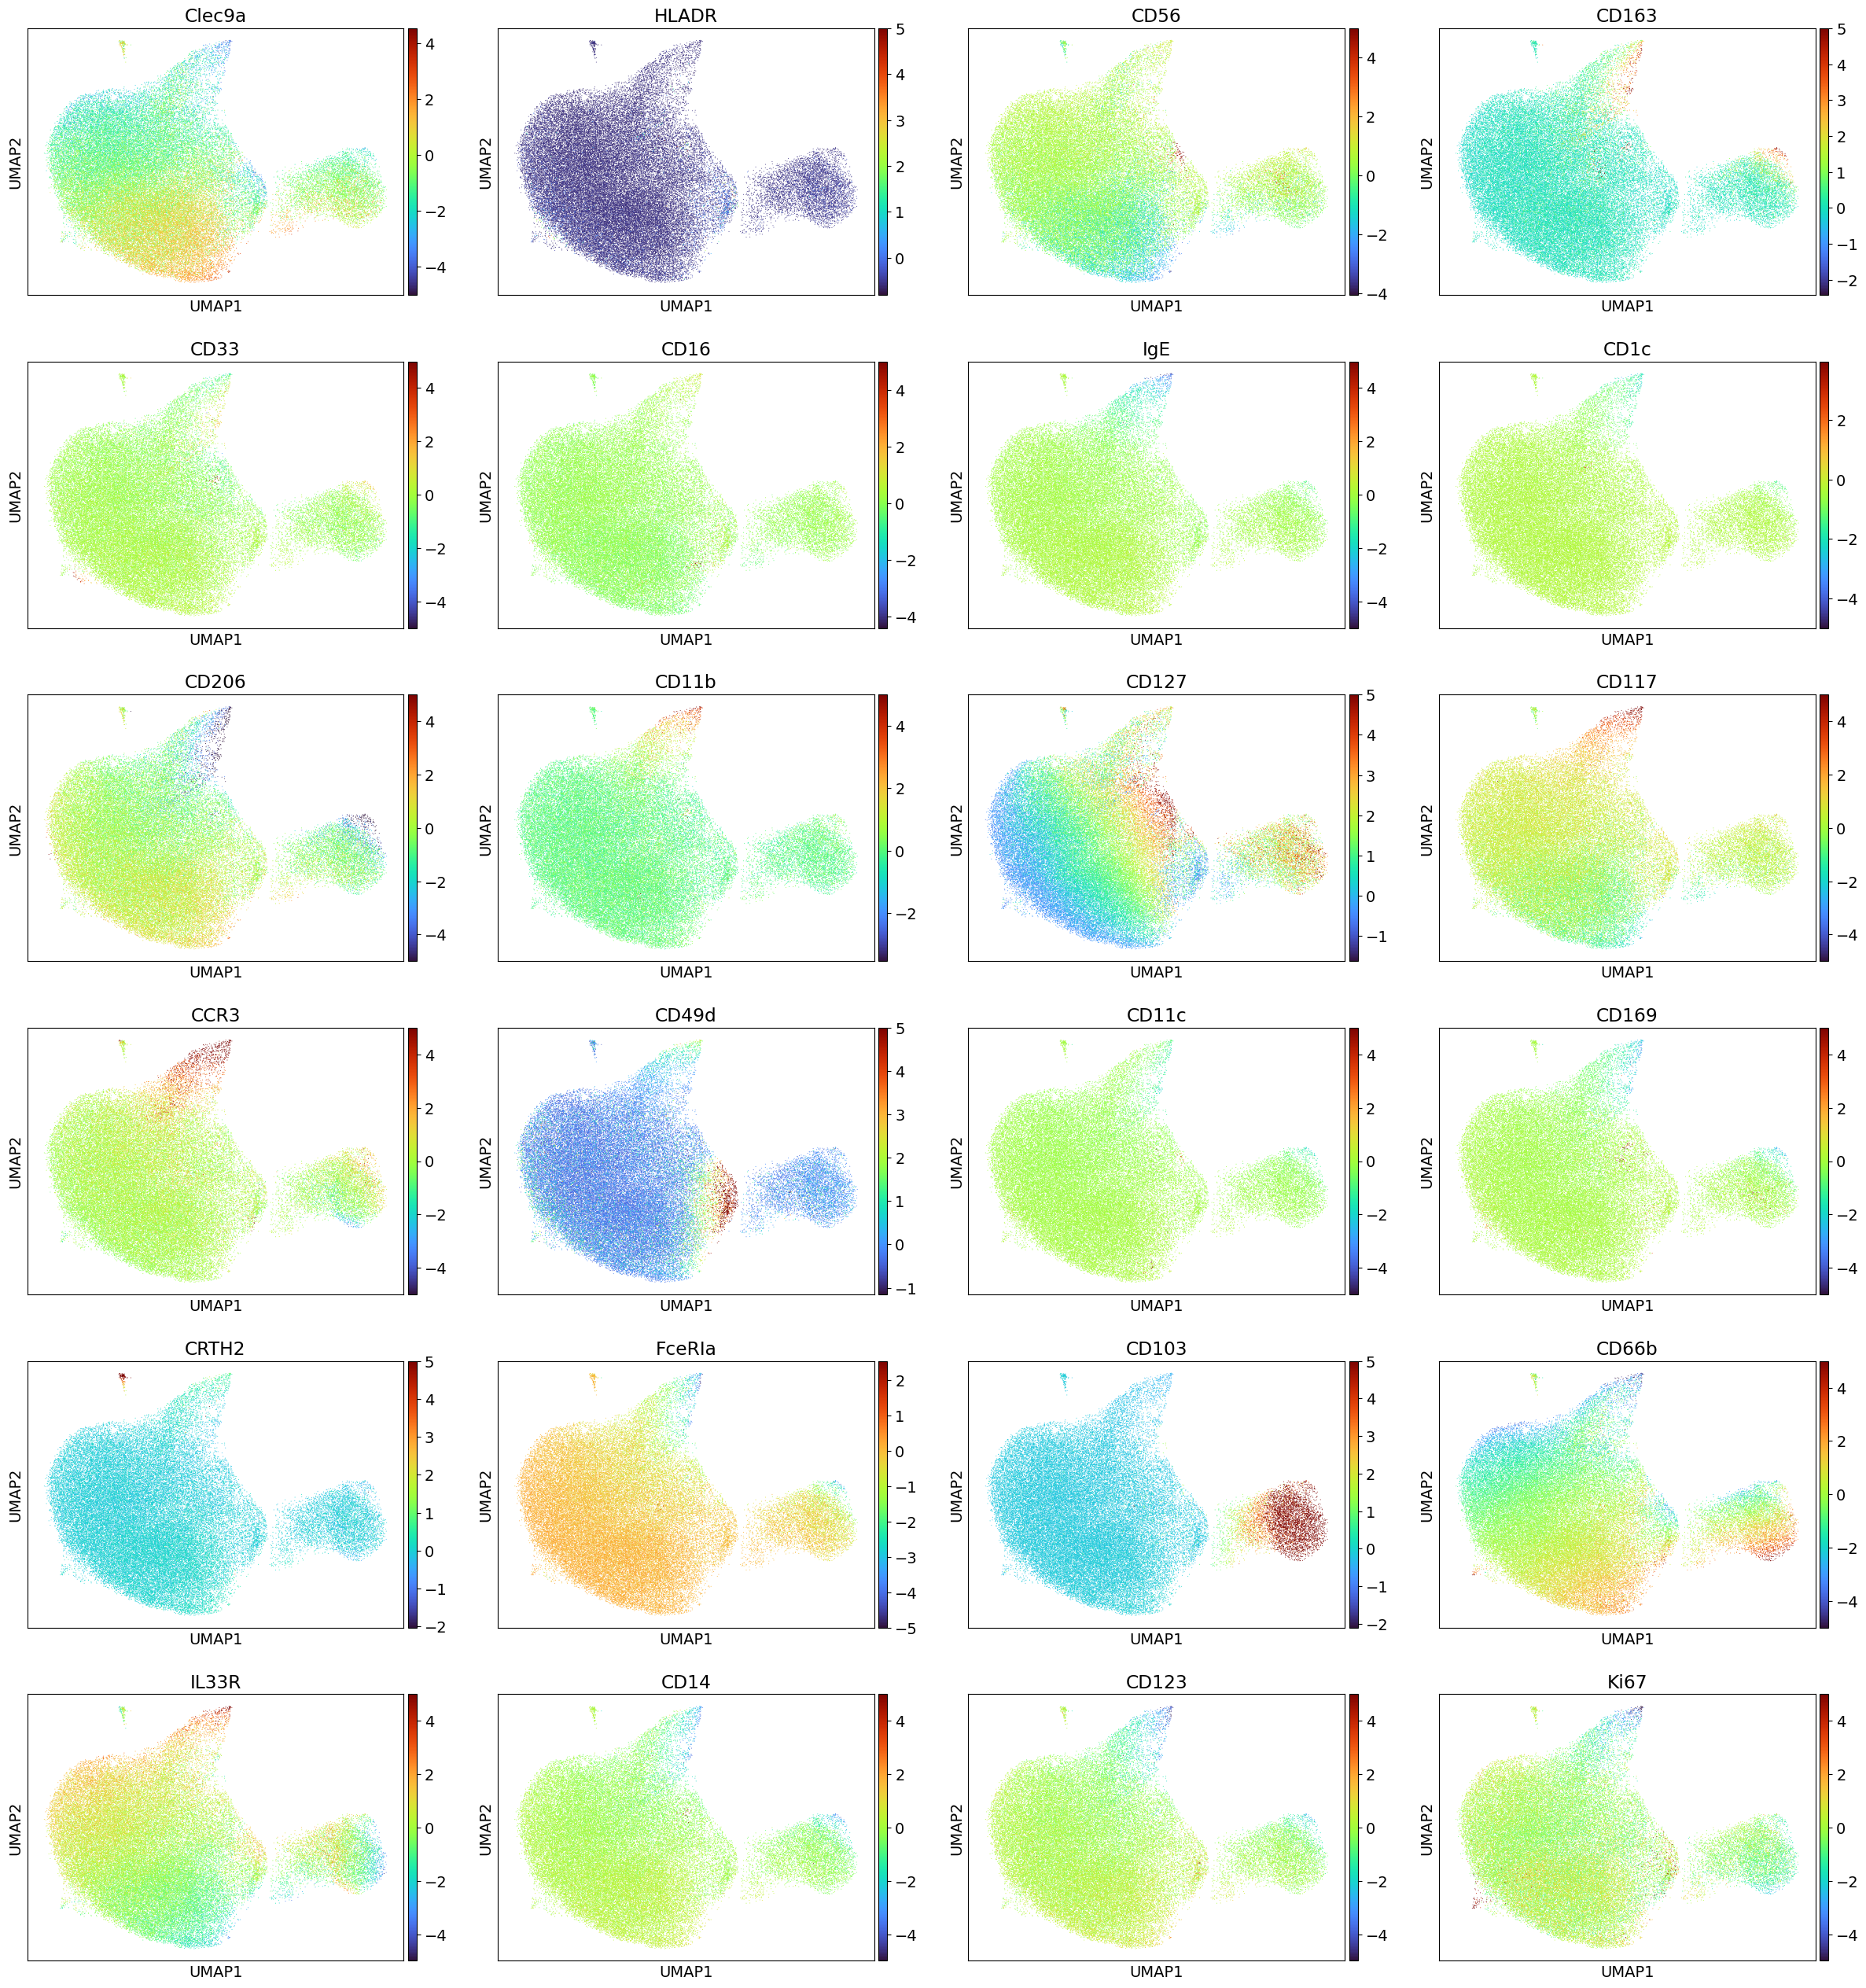

In [31]:
plt.rcParams.update({'font.size': 14})  
sc.pl.umap(sample, color=markers, cmap='turbo')

In [32]:
sc.tl.rank_genes_groups(sample, "leiden", method="wilcoxon")
df = pd.DataFrame(
    {group: sample.uns["rank_genes_groups"]["names"][group] for group in sample.uns["rank_genes_groups"]["names"].dtype.names}
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


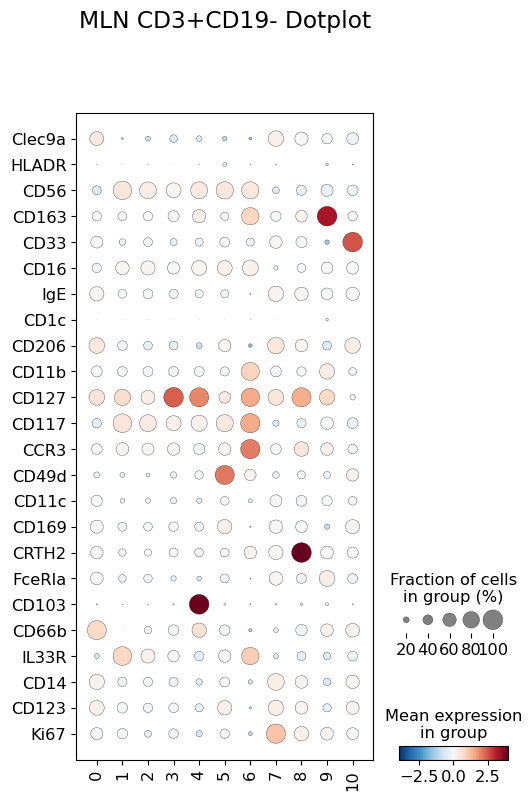

In [33]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

In [34]:
celltype = {'celltype': []}
cluster_to_genes = {
   '0': 'Clec9a+CD206+CD127+CD66b+ (0)',
   '1': 'CD56+CD127+CD117+IL33R+ (1)',
   '2': 'CD56+CD117+ (2)',
   '3': 'CD127+ (3)',
   '4': 'CD127+CD103+ (4)',
   '5': 'CD49d+ (5)',
   '6': 'CD163+CD11b+CD127+CD117+CCR3+IL33R+ (6)',
   '7': 'Ki67+ (7)',
   '8': 'CD127+CRTH2+ (8)',
   '9': 'CD163+ (9)',
   '10': 'CD33+ (10)'
}
celltype['celltype'] = [cluster_to_genes[leiden] for leiden in sample.obs['leiden']]
sample.obs["celltype"] = celltype['celltype']

print(sample.obs[["leiden", "celltype"]].head())

       leiden                       celltype
333297      1    CD56+CD127+CD117+IL33R+ (1)
253023      0  Clec9a+CD206+CD127+CD66b+ (0)
223271      5                     CD49d+ (5)
145927      2                CD56+CD117+ (2)
152469      4               CD127+CD103+ (4)


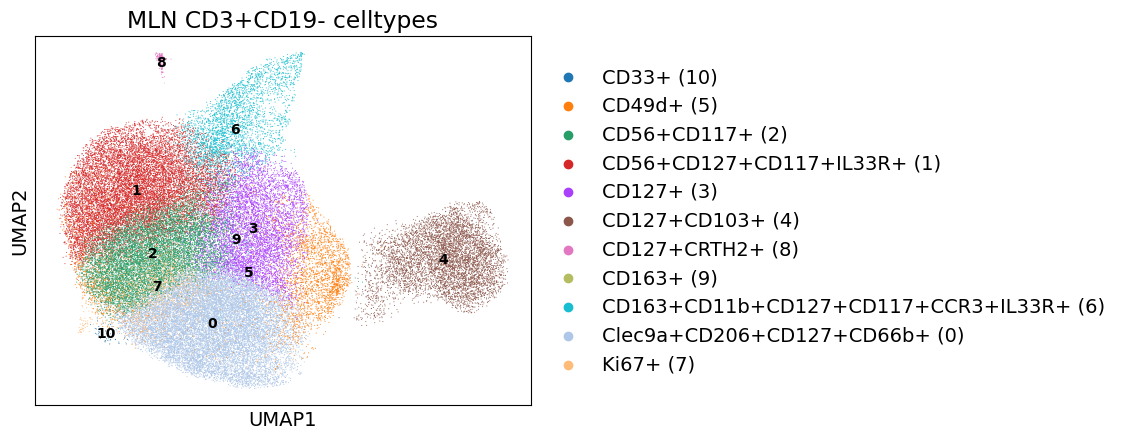

In [35]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.umap(
    sample,
    color=['celltype'],
    cmap='turbo',
    title = '{} {} celltypes'.format(tissue_type, sample_name),
    show=False,            
)

ax = plt.gca() 
for cluster in sample.obs['leiden'].cat.categories:
    cluster_mask = sample.obs['leiden'] == cluster
    cluster_coords = sample.obsm['X_umap'][cluster_mask]
    x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
    ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

plt.show()

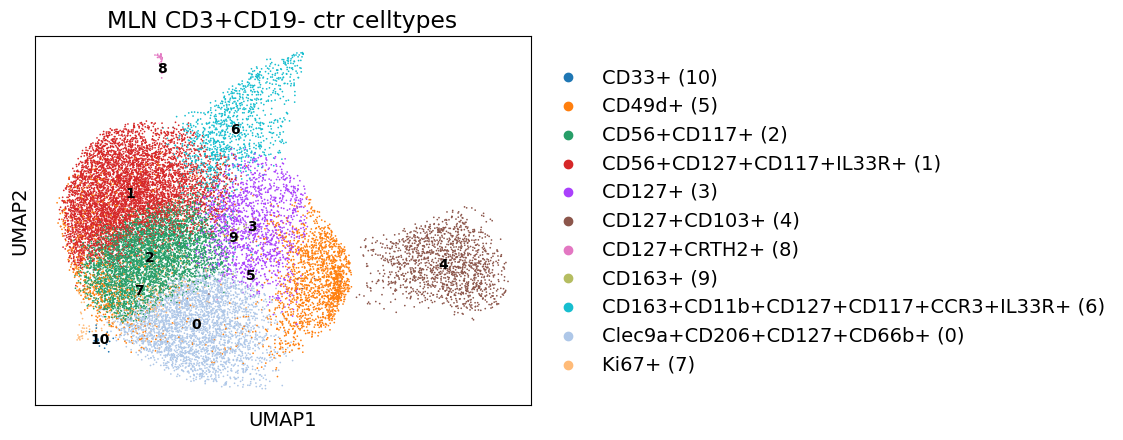

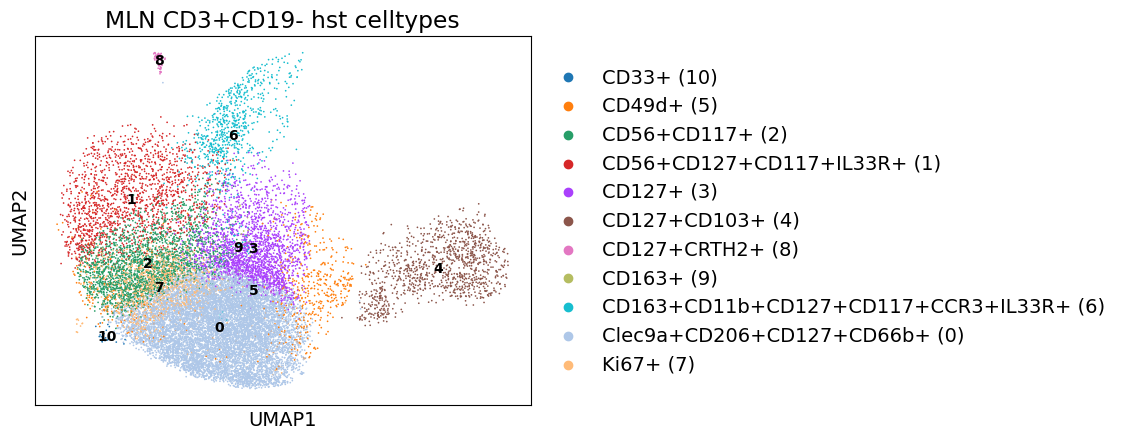

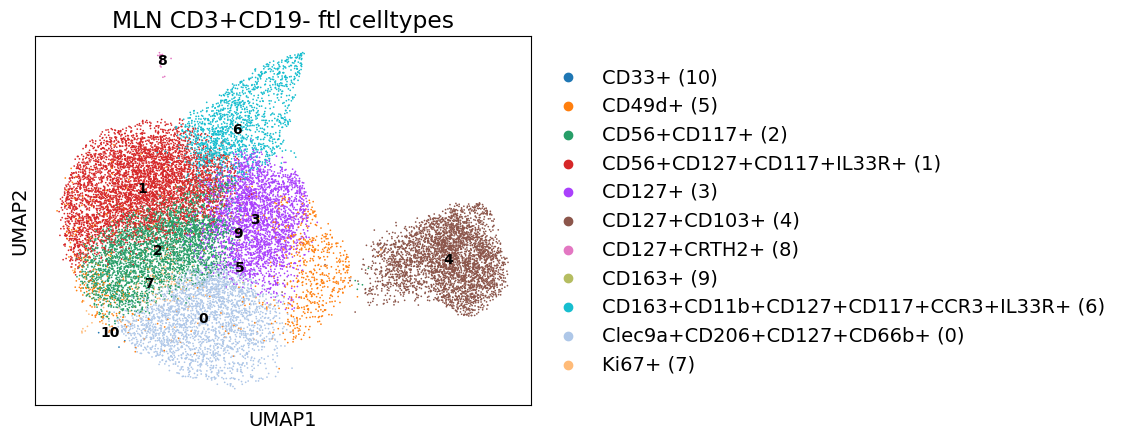

In [36]:
for group in ['ctr', 'hst', 'ftl']:
    adata_group = sample[sample.obs['group'] == group]
    
    sc.pl.umap(
    adata_group,
    color=['celltype'],
    title=f'{tissue_type} {sample_name} {group} celltypes',
    cmap='turbo', 
    show=False             
)

    ax = plt.gca()  
    for cluster in adata_group.obs['leiden'].cat.categories:
        cluster_mask = adata_group.obs['leiden'] == cluster
        cluster_coords = adata_group.obsm['X_umap'][cluster_mask]
        x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
        ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

    plt.show()

In [37]:
plt.rcParams.update({'font.size': 12})  

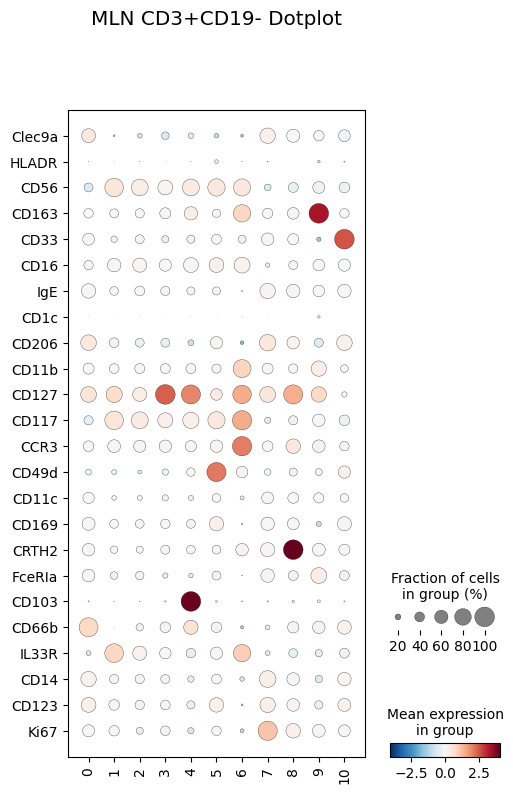

In [38]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

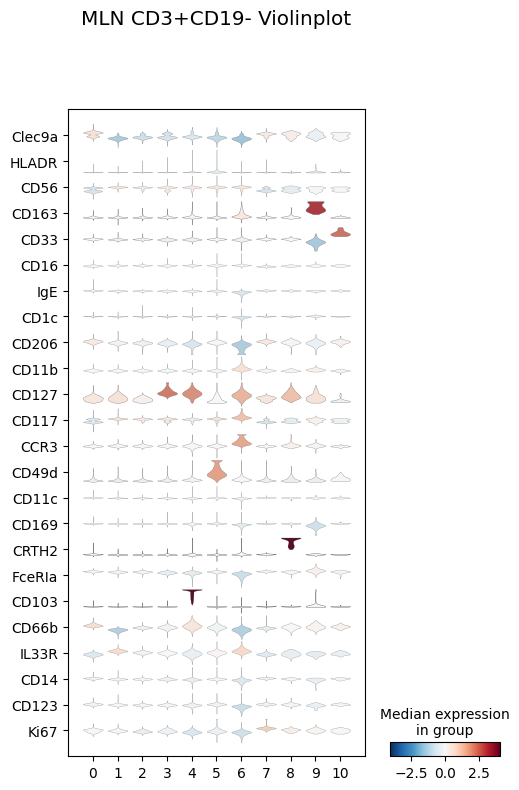

In [39]:
sc.pl.stacked_violin(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Violinplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)